In [33]:
import kagglehub
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.diagnostic import lilliefors
from statsmodels.stats.stattools import jarque_bera, durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as stats

# 1 Persiapan data

## 1.1 Load data

In [13]:
path = kagglehub.dataset_download("joebeachcapital/top-500-hollywood-movies-of-all-time")

csv_file = [f for f in os.listdir(path) if f.endswith(".csv")][0]
movies_df = pd.read_csv(os.path.join(path, "Most Profitable Movies of All Time - Top 500 Movies.csv"))

movies_df.head()

,title,worldwide gross (m),% budget recovered,X times budget recovered,budget (millions),domestic gross (m),domestic %,international gross (m),% of gross from international,worldwide gross,year,decade,source,budget source,force label,horror
0,300,456.0,702%,7.0,65.0,211.0,46.2%,245.0,53.8%,456082343,2007,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror
1,1917,385.0,427%,4.3,90.0,159.0,41.4%,225.0,58.6%,384576334,2019,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://www.nytimes.com/2020/01/12/movies/1917...,NaN,not horror
2,2012,791.0,396%,4.0,200.0,166.0,21.0%,625.0,79.0%,791217826,2009,2000's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror
3,101 Dalmatians,321.0,479%,4.8,67.0,136.0,42.5%,185.0,57.5%,320689294,1996,1990's,https://www.boxofficemojo.com/chart/ww_top_lif...,https://en.wikipedia.org/wiki/101_Dalmatians_(...,NaN,not horror
4,22 Jump Street,331.0,663%,6.6,50.0,192.0,57.9%,140.0,42.1%,331333876,2014,2010's,https://www.boxofficemojo.com/chart/ww_top_lif...,NaN,NaN,not horror


## 1.2 Data cleaning

In [14]:
# cek missing values
missing_values = movies_df.isnull().sum()

# cek duplicate rows
duplicate_rows = movies_df.duplicated().sum()

# cek data types
data_types = movies_df.dtypes

missing_values, duplicate_rows, data_types

(title                              0
 worldwide gross (m)                0
 % budget recovered                 0
 X times budget recovered           0
 budget  (millions)                 0
 domestic gross (m)                 0
 domestic %                         0
 international gross (m)            0
 % of gross from international      0
 worldwide gross                    0
 year                               0
 decade                             0
 source                            81
 budget source                    163
 force label                      557
 horror                             0
 dtype: int64,
 np.int64(0),
 title                                str
 worldwide gross (m)              float64
 % budget recovered                   str
 X times budget recovered         float64
 budget  (millions)               float64
 domestic gross (m)               float64
 domestic %                           str
 international gross (m)          float64
 % of gross from internatio

In [15]:
# ganti nama kolom
movies_df = movies_df.rename(columns={
    "budget  (millions)": "budget_millions",
    "worldwide gross (m)": "worldwide_gross_m"
})

# rumus regresi
formula = "worldwide_gross_m ~ budget_millions"

# fit model
model = ols(formula, data=movies_df).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      worldwide_gross_m   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     358.3
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           3.90e-62
Time:                        14:30:47   Log-Likelihood:                -3962.3
No. Observations:                 562   AIC:                             7929.
Df Residuals:                     560   BIC:                             7937.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         214.1501     20.558     

## 2 EDA

## 2.1 Statistik deskriptif

In [16]:
movies_df[["budget_millions", "worldwide_gross_m"]].describe()

,budget_millions,worldwide_gross_m
count,562.000000,562.000000
mean,108.460614,532.883986
std,76.027601,357.689672
min,0.015000,4.000000
25%,43.250000,342.000000
50%,100.000000,432.000000
75%,165.000000,667.750000
max,379.000000,2923.000000


## 2.2 Distribusi variabel X dan Y

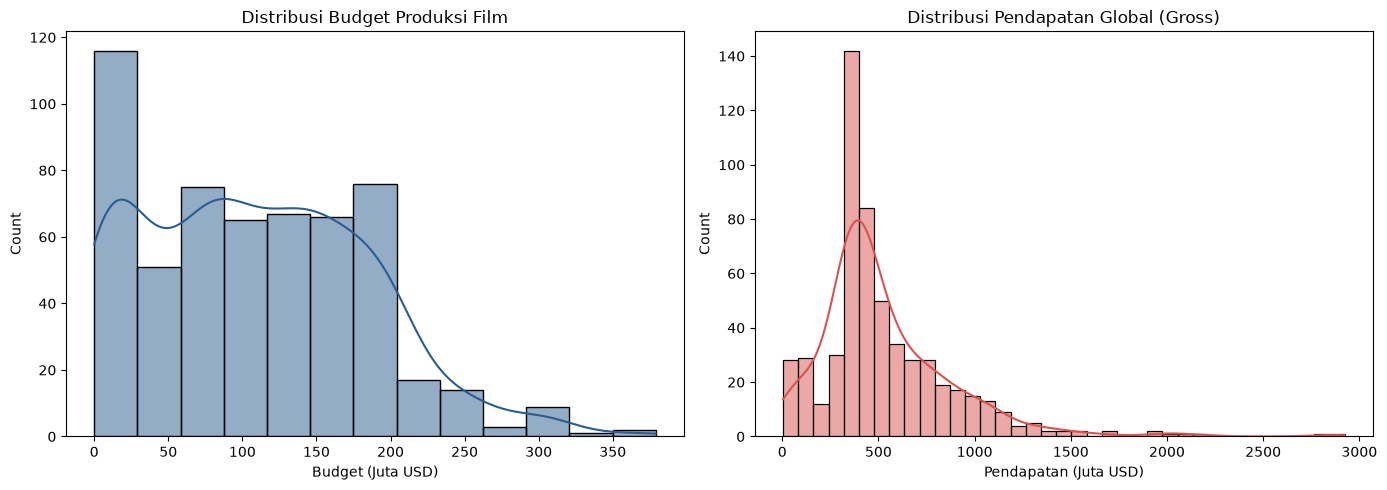

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# budget
sns.histplot(movies_df["budget_millions"], kde=True, color="#2b5c8f", ax=ax[0])
ax[0].set_title("Distribusi Budget Produksi Film")
ax[0].set_xlabel("Budget (Juta USD)")

# gross
sns.histplot(movies_df["worldwide_gross_m"], kde=True, color="#d9534f", ax=ax[1])
ax[1].set_title("Distribusi Pendapatan Global (Gross)")
ax[1].set_xlabel("Pendapatan (Juta USD)")

plt.tight_layout()
plt.show()

## 2.3 Cek outlier

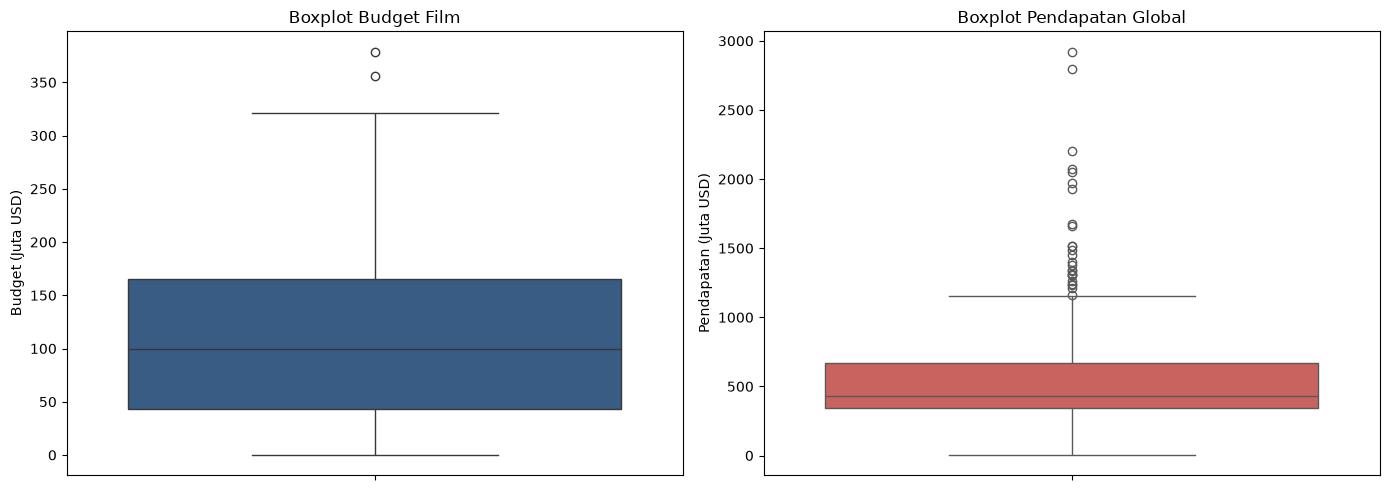

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# budget
sns.boxplot(y=movies_df["budget_millions"], color="#2b5c8f", ax=ax[0])
ax[0].set_title("Boxplot Budget Film")
ax[0].set_ylabel("Budget (Juta USD)")

# gross
sns.boxplot(y=movies_df["worldwide_gross_m"], color="#d9534f", ax=ax[1])
ax[1].set_title("Boxplot Pendapatan Global")
ax[1].set_ylabel("Pendapatan (Juta USD)")

plt.tight_layout()
plt.show()

## 2.4 Hubungan antar variabel

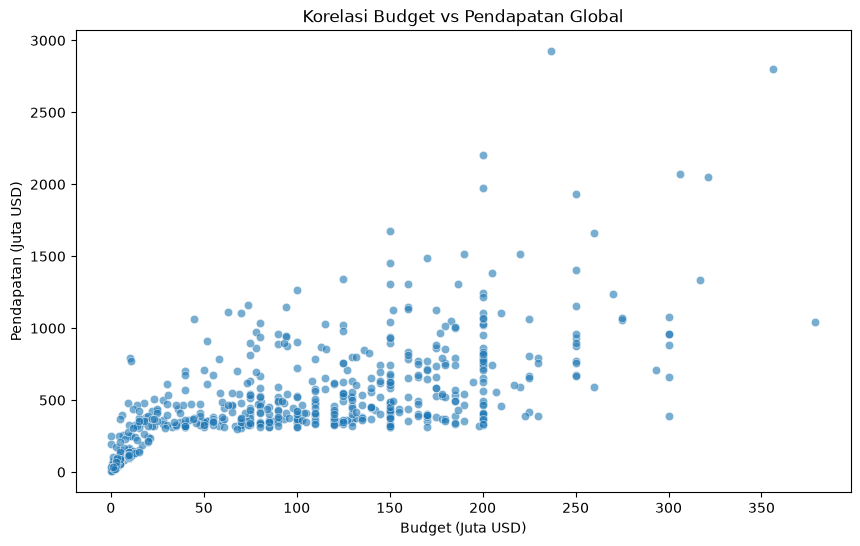

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=movies_df,
    x="budget_millions",
    y="worldwide_gross_m",
    alpha=0.6
)
plt.title("Korelasi Budget vs Pendapatan Global")
plt.xlabel("Budget (Juta USD)")
plt.ylabel("Pendapatan (Juta USD)")
plt.show()

# 3. Model regresi linear sederhana

## 3.1 Persamaan garis regresi linear sederhana

In [23]:
formula = "worldwide_gross_m ~ budget_millions"

model = ols(formula, data=movies_df).fit()

print(model.summary())

                            OLS Regression Results                            
Dep. Variable:      worldwide_gross_m   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     358.3
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           3.90e-62
Time:                        15:30:53   Log-Likelihood:                -3962.3
No. Observations:                 562   AIC:                             7929.
Df Residuals:                     560   BIC:                             7937.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept         214.1501     20.558     

In [ ]:
a = model.params["budget_millions"]
b = model.params["Intercept"]

print("Persamaan garis regresi:")
print(f"Y = {a:.4f}X + {b:.4f}")
print(f"Worldwide Gross = {a:.4f}(Budget) + {b:.4f}")

Persamaan garis regresi:
Y = 2.9387X + 214.1501
Worldwide Gross = 2.9387(Budget) + 214.1501


## 3.2 Plot garis regresi

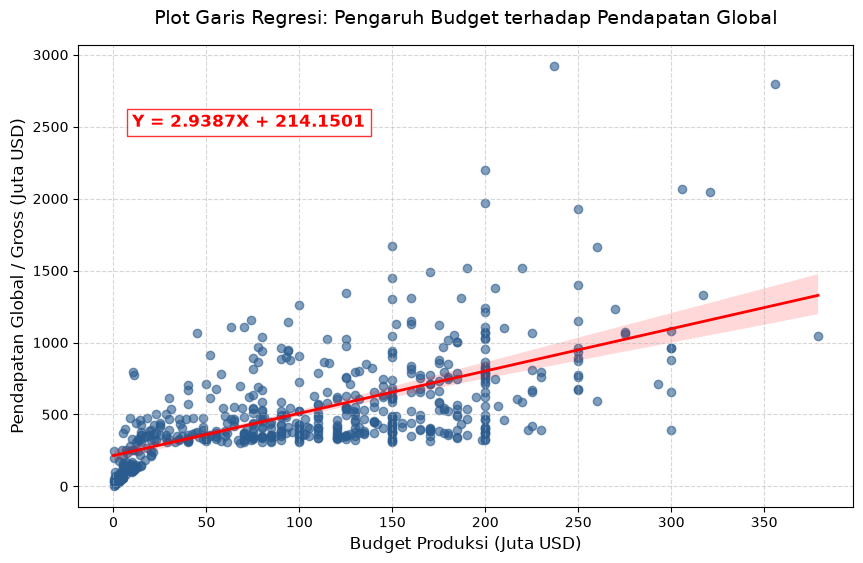

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ukuran kanvas
plt.figure(figsize=(10, 6))

# scatter plot dan garis regresi
sns.regplot(
    x="budget_millions",
    y="worldwide_gross_m",
    data=movies_df, 
    scatter_kws={"alpha": 0.6, "color": "#2b5c8f"},
    line_kws={"color": "red", "linewidth": 2}
)

# judul, label sumbu
plt.title("Plot Garis Regresi: Pengaruh Budget terhadap Pendapatan Global", fontsize=14, pad=15)
plt.xlabel("Budget Produksi (Juta USD)", fontsize=12)
plt.ylabel("Pendapatan Global / Gross (Juta USD)", fontsize=12)

# label persamaan regresi
plt.text(
    x=10,
    y=2500,
    s=f"Y = {a:.4f}X + {b:.4f}", 
    fontsize=12,
    color="red",
    weight="bold", 
    bbox=dict(facecolor="white", alpha=0.8, edgecolor="red")
)

# grid
plt.grid(True, linestyle="--", alpha=0.5)

# plot
plt.show()

# 4 Uji asumsi

In [29]:
residuals = model.resid
exog_variables = model.model.exog

## 4.1 Uji normalitas residual (Uji Lilliefors)

### 4.1.1 Hipotesis

$H_0$: Data residual berdistribusi normal. <br>
$H_1$: Data residual tidak berdistribusi normal.

### 4.1.2 Taraf signifikansi

In [45]:
alpha = 0.05
print(f"Taraf signifikansi (\u03b1): {alpha}\n")

Taraf signifikansi (α): 0.05



### 4.1.3 P-value

In [ ]:
ks_stat, p_value = lilliefors(residuals)

print(f"Statistik uji (D): {ks_stat:.4f}")
print(f"P-value: {p_value:.6f}\n")

Statistik uji (D): 0.1379
P-value: 0.001000



### 4.1.4 Keputusan

In [44]:
if p_value < alpha:
    print(f"P-value ({p_value:.6f}) < \u03b1 ({alpha}) -> Tolak H0\n")
else:
    print(f"P-value ({p_value:.6f}) >= \u03b1 ({alpha}) -> Gagal tolak H0\n")

P-value (0.001000) < α (0.05) -> Tolak H0



### 4.1.5 Kesimpulan

In [38]:
if p_value < alpha:
    print(f"Pada taraf signifikansi {alpha}, terdapat cukup bukti empiris untuk menolak H0.")
    print("Artinya: Data residual tidak berdistribusi normal (asumsi terlanggar).")
else:
    print(f"Pada taraf signifikansi {alpha}, tidak cukup bukti empiris untuk menolak H0.")
    print("Artinya: Data residual berdistribusi normal (asumsi terpenuhi).")

Pada taraf signifikansi 0.05, terdapat cukup bukti empiris untuk menolak H0.
Artinya: Data residual tidak berdistribusi normal (asumsi terlanggar).


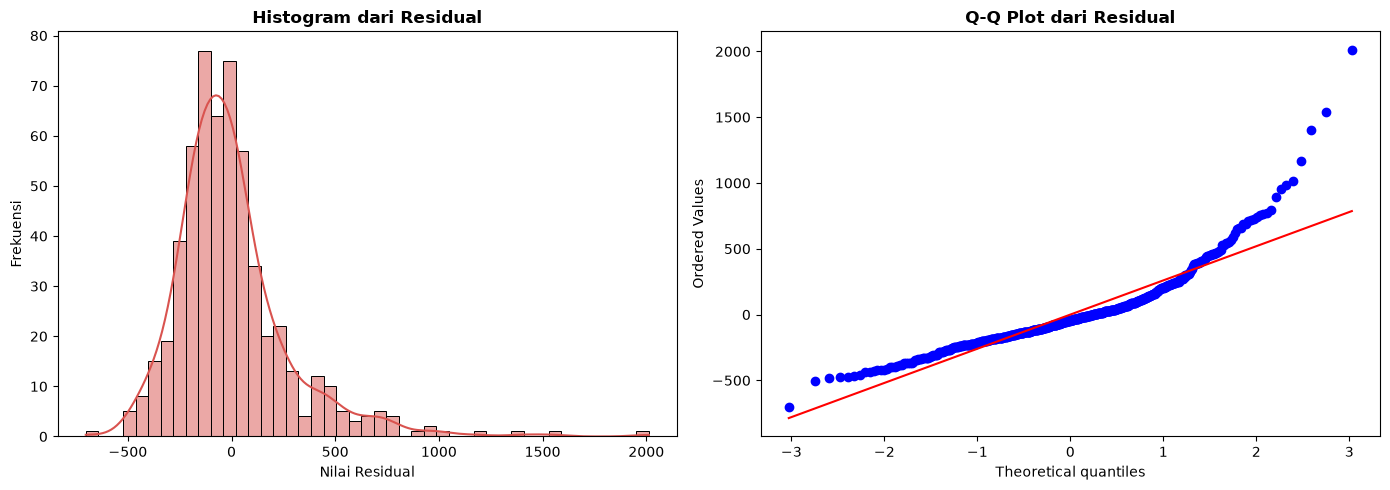

In [52]:
# nilai residual dari model regresi
residuals_asli = model.resid

# tata letak grafik
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# histogram residual
sns.histplot(residuals_asli, kde=True, ax=ax[0], color="#d9534f")
ax[0].set_title("Histogram dari Residual", fontweight="bold")
ax[0].set_xlabel("Nilai Residual")
ax[0].set_ylabel("Frekuensi")

# Q-Q Plot
stats.probplot(residuals_asli, dist="norm", plot=ax[1])
ax[1].set_title("Q-Q Plot dari Residual", fontweight="bold")

plt.tight_layout()
plt.show()

## 4.2 Uji heteroskedastisitas (Uji Breusch-Pagan)

### 4.2.1 Hipotesis

$H_0$: Varians residual bersifat konstan dari waktu ke waktu (homoskedastisitas). <br>
$H_1$: Varians residual tidak bersifat konstan dari waktu ke waktu (heteroskedastisitas).

### 4.2.2 Taraf signifikansi

In [39]:
alpha = 0.05
print(f"Taraf signifikansi (\u03b1) : {alpha}\n")

Taraf signifikansi (α) : 0.05



### 4.2.3 P-value

In [41]:
exog_variables = model.model.exog

bp_test = het_breuschpagan(residuals, exog_variables)

lm_stat = bp_test[0]
p_value_bp = bp_test[1]

print(f"Statistik uji (LM): {lm_stat:.4f}")
print(f"P-value: {p_value_bp:.6f}\n")

Statistik uji (LM): 40.9297
P-value: 0.000000



### 4.2.4 Keputusan

In [46]:
if p_value_bp < alpha:
    print(f"P-value ({p_value_bp:.6f}) < \u03b1 ({alpha}) -> Tolak H0\n")
else:
    print(f"P-value ({p_value_bp:.6f}) >= \u03b1 ({alpha}) -> Gagal tolak H0\n")

P-value (0.000000) < α (0.05) -> Tolak H0



### 4.2.5 Kesimpulan

In [50]:
if p_value_bp < alpha:
    print(f"Pada taraf signifikansi {alpha}, terdapat cukup bukti empiris untuk menolak H0.")
    print("Artinya: Varians residual tidak konstan (asumsi terlanggar).")
else:
    print(f"Pada taraf signifikansi {alpha}, tidak terdapat cukup bukti empiris untuk menolak H0.")
    print("Artinya: Varians residual konstan (ssumsi terpenuhi).")

Pada taraf signifikansi 0.05, terdapat cukup bukti empiris untuk menolak H0.
Artinya: Varians residual tidak konstan (asumsi terlanggar).


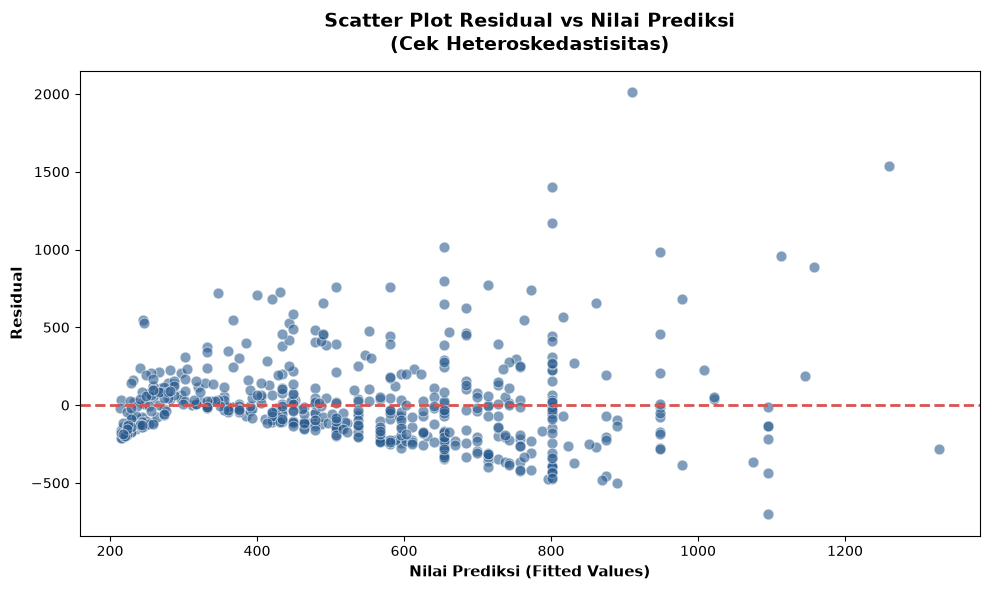

In [53]:
# nilai rrediksi dan residual dari model asli
fitted_values = model.fittedvalues
residuals_asli = model.resid

# ukuran grafik
plt.figure(figsize=(10, 6))

# scatter plot (fitted vs residual)
sns.scatterplot(
    x=fitted_values, 
    y=residuals_asli, 
    color="#2b5c8f", 
    alpha=0.6, 
    s=60
)

# garis nol sebagai batas tengah error
plt.axhline(y=0, color="#d9534f", linestyle="--", linewidth=2)

# judul dan label
plt.title("Scatter Plot Residual vs Nilai Prediksi\n(Cek Heteroskedastisitas)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Nilai Prediksi (Fitted Values)", fontsize=11, fontweight="bold")
plt.ylabel("Residual", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.show()

In [54]:
formula = "worldwide_gross_m ~ budget_millions"

# tambahkan cov_type="HC3"
model_robust = ols(formula, data=movies_df).fit(cov_type="HC3")

print("Hasil regresi dengan robust standard errors:")
print(model_robust.summary())

Hasil regresi dengan robust standard errors:
                            OLS Regression Results                            
Dep. Variable:      worldwide_gross_m   R-squared:                       0.390
Model:                            OLS   Adj. R-squared:                  0.389
Method:                 Least Squares   F-statistic:                     171.1
Date:                Fri, 18 Sep 2026   Prob (F-statistic):           2.64e-34
Time:                        17:40:10   Log-Likelihood:                -3962.3
No. Observations:                 562   AIC:                             7929.
Df Residuals:                     560   BIC:                             7937.
Df Model:                           1                                         
Covariance Type:                  HC3                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------

In [57]:
# model regresi dengan robust standard errors (HC3)
model_robust = ols("worldwide_gross_m ~ budget_millions", data=movies_df).fit(cov_type='HC3')

# konstanta dan koefisien dari model robust
intercept = model_robust.params['Intercept']
koefisien_budget = model_robust.params['budget_millions']

# persamaan garis regresi
print("Persamaan garis regresi (Robust HC3):")
print(f"Worldwide Gross = {intercept:.4f} + {koefisien_budget:.4f} * Budget")

Persamaan garis regresi (Robust HC3):
Worldwide Gross = 214.1501 + 2.9387 * Budget


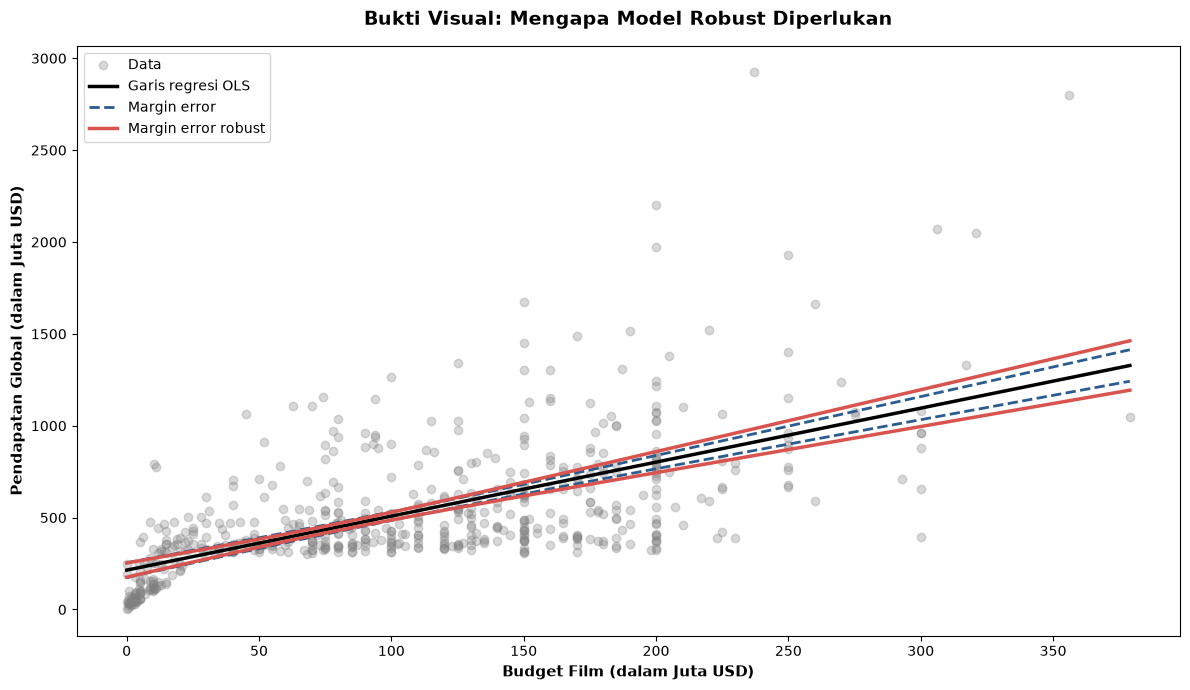

In [59]:
# rentang X
x_range = pd.DataFrame({"budget_millions": np.linspace(movies_df["budget_millions"].min(), movies_df["budget_millions"].max(), 100)})

# nilai prediksi & batas confidence interval
pred_biasa = model.get_prediction(x_range).summary_frame(alpha=0.05)
pred_robust = model_robust.get_prediction(x_range).summary_frame(alpha=0.05)

# grafik
plt.figure(figsize=(12, 7))

# scatter plot
plt.scatter(movies_df["budget_millions"], movies_df["worldwide_gross_m"], color="grey", alpha=0.3, label="Data")

# garis regresi
plt.plot(x_range["budget_millions"], pred_biasa["mean"], color="black", linewidth=2.5, label="Garis regresi OLS")

# model biasa
plt.plot(x_range["budget_millions"], pred_biasa["mean_ci_upper"], color="#2b5c8f", linestyle="--", linewidth=2, label="Margin error")
plt.plot(x_range["budget_millions"], pred_biasa["mean_ci_lower"], color="#2b5c8f", linestyle="--", linewidth=2)

# model robust HC3
plt.plot(x_range["budget_millions"], pred_robust["mean_ci_upper"], color="#d9534f", linestyle="-", linewidth=2.5, label="Margin error robust")
plt.plot(x_range["budget_millions"], pred_robust["mean_ci_lower"], color="#d9534f", linestyle="-", linewidth=2.5)

# visual
plt.title("Bukti Visual: Mengapa Model Robust Diperlukan", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Budget Film (dalam Juta USD)", fontsize=11, fontweight="bold")
plt.ylabel("Pendapatan Global (dalam Juta USD)", fontsize=11, fontweight="bold")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

## Uji hipotesis (Uji Z)

### Hipotesis

H0: $\beta_1=0$ (Anggaran produksi tidak memengaruhi pendapatan global secara signifikan.) <br>
H1: $\beta_1 \neq 0$ (Anggaran produksi memengaruhi pendapatan global secara signifikan.)

### Nilai kritis

In [20]:
alpha = 0.05
z_kritis = stats.norm.ppf(1 - alpha/2)

print(f"Taraf signifikansi \u03b1: {alpha}")
print(f"Nilai kritis: +/- {z_kritis:.3f}")

Taraf signifikansi α: 0.05
Nilai kritis: +/- 1.960


### Statistik uji

In [60]:
t_hitung = model.tvalues["budget_millions"]
p_value = model.pvalues["budget_millions"]

print(f"Statistik uji (t-hitung) : {t_hitung:.3f}")
print(f"p-value                  : {p_value:.6f}")

Statistik uji (t-hitung) : 18.928
p-value                  : 0.000000


### Keputusan

In [ ]:
# nilai Z
if abs(z_hitung) > z_kritis:
    print(f"Z-Hitung ({abs(z_hitung):.3f}) > Z-Tabel ({z_kritis:.3f}) -> Tolak H0")
else:
    print(f"Z-Hitung ({abs(z_hitung):.3f}) <= Z-Tabel ({z_kritis:.3f}) -> GAGAL Tolak H0")

# p-value
if p_value < alpha:
    print(f"P-Value ({p_value:.6f}) < Alpha ({alpha}) -> Tolak H0")
else:
    print(f"P-Value ({p_value:.6f}) >= Alpha ({alpha}) -> GAGAL Tolak H0")

Z-Hitung (13.080) > Z-Tabel (1.960) -> TOLAK H0
P-Value (0.000000) < Alpha (0.05) -> TOLAK H0


### Kesimpulan

In [ ]:
if p_value < alpha:
    print("Dengan tingkat keyakinan 95%, terdapat cukup bukti empiris untuk menolak H0.")
    print("Artinya, anggaran produksi terbukti memiliki pengaruh yang positif dan signifikan terhadap pendapatan kotor global.")
else:
    print("Tidak cukup bukti empiris untuk menolak H0.")
    print("Artinya, anggaran produksi tidak terbukti memengaruhi pendapatan kotor global secara signifikan.")

Dengan tingkat keyakinan 95%, terdapat cukup bukti empiris untuk menolak H0.
Artinya, anggaran produksi terbukti memiliki pengaruh yang positif dan signifikan terhadap pendapatan kotor global.


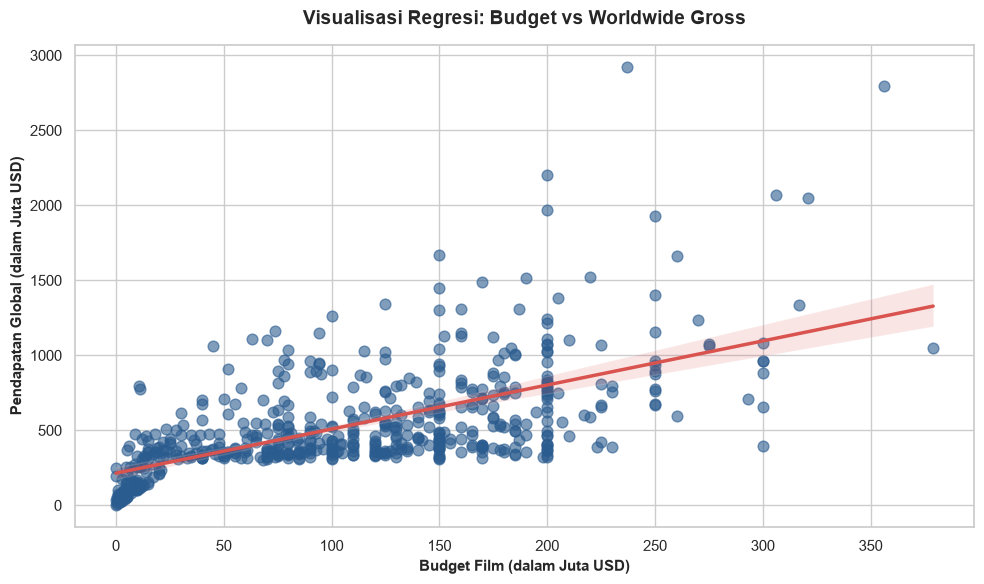

In [ ]:
# tema
sns.set_theme(style="whitegrid")

# ukuran grafik
plt.figure(figsize=(10, 6))

# scatter plot, garis regresi
sns.regplot(
    data=movies_df, 
    x="budget_millions", 
    y="worldwide_gross_m",
    scatter_kws={"color": "#2b5c8f", "alpha": 0.6, "s": 60},
    line_kws={"color": "#d9534f", "linewidth": 2.5}
)

# judul, label sumbu
plt.title("Visualisasi Regresi: Budget vs Worldwide Gross", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Budget Film (dalam Juta USD)", fontsize=11, fontweight="bold")
plt.ylabel("Pendapatan Global (dalam Juta USD)", fontsize=11, fontweight="bold")

# grafik
plt.tight_layout()
plt.show()